In [5]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [1]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [11]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

#Making Time Matrix
Nt=len(data['time'])
T = np.broadcast_to(np.arange(Nt)[:, None], A_c.shape)  # shape: (Nt, p)

In [6]:
#READING BACK IN
mins_thresh=5
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed = h5file['A_g_Processed'][:]
    A_c_Processed = h5file['A_c_Processed'][:]

In [27]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=(data['xf'][-1].item()-data['xf'][0].item())*1000 #x length (m)
Ly=(data['yf'][-1].item()-data['yf'][0].item())*1000 #y length (m)
Lx/=1000;Ly/=1000#TESTING*******
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [30]:
def MF2d(A, T, Z):
    start_time = time.time()
    """
    Function to compute 2D Mass Flux and update result array based on provided inputs.
    
    Returns a 2D (t,z) array containing the sum of the D array represented by parcels in cloudy updrafts by 1.
    The finally array is then ordered by the appropiate index using the np.add.at function.
    
    Parameters:
    - A: The (t,p) lagrangian binary array.
    - T: The (t,p) lagrangian time index array.
    - Z: The (t,p) Lagrangian z index array.

    """
    # Compute the difference between neighboring elements along the first axis
    D = np.zeros_like(A)
    D[1:, :] = A[1:, :] #- A[:-1, :]
    
    # # Update D for entrainment/detrainment
    # if type=='e':
    #     D[D <= 0] = 0
    # elif type=='d':
    #     D[D >= 0] = 0
    
    # Initialize time and vertical dimension arrays
    Nt = len(data['time']); Nz = len(data['zh'])
    
    # Initialize result array
    result = np.zeros((Nt, Nz))
    
    # Use np.add.at to accumulate values in the result array
    np.add.at(result, (T, Z), D)
    
    end_time = time.time()
    print(f"Execution time: {(end_time - start_time)} seconds")
    return result

In [31]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
PROCESSING=True

# Set A based on PROCESSING state
A = A_g if (PROCESSING==False) else A_g_Processed
profile_array_MF_g = MF2d(A, T, Z)


# Set A for the second block
A = A_c if (PROCESSING==False) else A_c_Processed
profile_array_MF_c = MF2d(A, T, Z)


#SAVING
if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_MF_profiles_{res}_{Np_str}.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_MF_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_MF_g", data=profile_array_MF_g)
    h5f.create_dataset("profile_array_MF_c", data=profile_array_MF_c)
print('done')

Execution time: 21.72360920906067 seconds
Execution time: 14.711551904678345 seconds
done


In [32]:
def apply_constant(profile_array,apply):
    if apply==True:
        Nt=profile_array.shape[0]
        Nz=profile_array.shape[1]
    
        profile_array/=(Lx*Ly)
        for t in np.arange(Nt):
            profile_array[t]*=m(t)
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[:,z]/=dz
    return profile_array

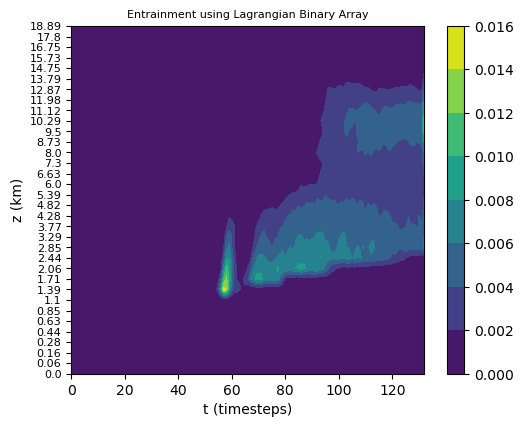

In [33]:
type='general'
type='cloudy'

dir3=dir+f'Project_Algorithms/Entrainment/2D_MF_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_MF_g = h5f["profile_array_MF_g"][:]
    profile_array_MF_c = h5f["profile_array_MF_c"][:]
profile_array_MF_g=apply_constant(profile_array_MF_g,apply=True)
profile_array_MF_c=apply_constant(profile_array_MF_c,apply=True)


if type=='general':
    profile_array=profile_array_MF_g
if type=='cloudy':
    profile_array=profile_array_MF_c


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

# ######
# vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
# norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
# ######

# First subplot: VMF
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array.T, cmap=cmap1)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# #FIXING TICKS
# ax3.set_yticks(np.arange(Nz))
# new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
# ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
# ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
# ax3.set_title('Entrainment - Detrainment')

# #FIXING SCIENTIFIC NOTATION
# from matplotlib.ticker import ScalarFormatter
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
# for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
#     cbar.formatter = formatter
#     cbar.update_ticks()

# Display the plot
plt.tight_layout()

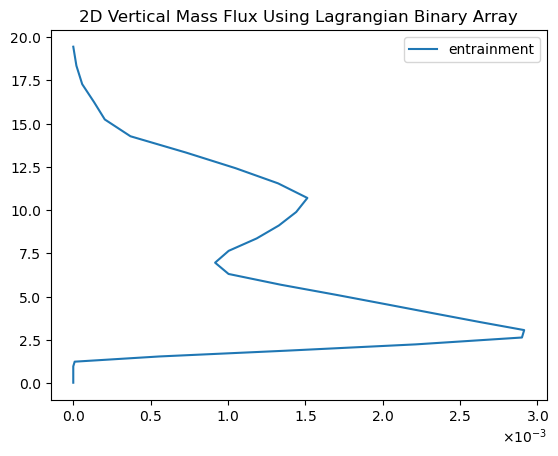

In [34]:
plt.plot(np.mean(profile_array,axis=(0)),data['zh'],label='entrainment')

plt.legend(); plt.title('2D Vertical Mass Flux Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)